# 03 — QAOA single run

One QAOA configuration end-to-end on the canonical 16-equity universe
(Mag7 + quantum + quantum_big + anti) at `K=4, p=3`: the multi-start
training spread, the top-5 most likely bitstrings, and the probability
mass on budget-feasible (K=4) states.

Defaults: 10 random `(gamma, beta)` inits, COBYLA `maxiter=200`,
`rhobeg=0.1`. Single-seed QAOA is not meaningful — the landscape is
non-convex enough that the multi-start is mandatory.

In [1]:
# === Colab Setup ===
import os, sys
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    repo_url = 'https://github.com/egil10/fys5419.git'
    repo_dir = '/content/fys5419'
    if not os.path.exists(repo_dir):
        get_ipython().system(f'git clone {repo_url} {repo_dir}')
    else:
        get_ipython().system(f'git -C {repo_dir} pull')
    os.chdir(f'{repo_dir}/project2/code/notebooks')

sys.path.append('..')
from scripts.colab import setup, out_dir; setup()

# === Project imports ===
import numpy as np
import matplotlib.pyplot as plt

from scripts.data      import load_universe
from scripts.portfolio import PortfolioProblem, DEFAULTS
from scripts.classical import brute_force
from scripts.qaoa      import solve, decode_top_k, make_hamiltonians
from scripts.metrics   import approximation_ratio, prob_optimal, prob_feasible
from scripts.plotting  import apply_style, PALETTE, title, fig_path
apply_style()

remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 14 (delta 10), reused 14 (delta 10), pack-reused 0 (from 0)
Unpacking objects: 100% (14/14), 943.20 KiB | 10.72 MiB/s, done.
From https://github.com/egil10/fys5419
   4e0c162..0301708  main       -> origin/main
Updating 4e0c162..0301708
Fast-forward
 project2/code/notebooks/01_eda.ipynb       | 190 +++++++++++++++++++++++--
 project2/code/notebooks/02_classical.ipynb |  90 +++++++++---
 project2/code/notebooks/04_depth.ipynb     | 220 ++++++++++++++++++++++++++++-
 3 files changed, 468 insertions(+), 32 deletions(-)
> /usr/bin/python3 -m pip install -q numpy pandas scipy matplotlib yfinance pyarrow
[colab.setup] env=Colab
[colab.setup] cwd  = /content/fys5419/project2/code/notebooks
[colab.setup] path = /content/fys5419/project2/code  (added to sys.path)


In [2]:
# === Canonical instance: n=16, K=4, p=3 ===
P = 3

r  = load_universe()
pf = PortfolioProblem(r.mu, r.Sigma,
                      lam=DEFAULTS['lam'], A=DEFAULTS['A'],
                      K=DEFAULTS['K_AT_16'], tickers=r.tickers)

bf  = brute_force(pf)
res = solve(pf, p=P, n_restarts=10, seed=42, verbose=False)

print(f'brute force:  x={bf.bitstring}  C={bf.cost:.6f}')
print(f'              picks: {bf.tickers(pf)}')
print(f'QAOA p={P}:     E={res["energy"]:.6f}  ratio={res["ratio"]:.4f}')
print(f'P(optimum)  = {prob_optimal(res["probs"], bf.x):.4f}')
print(f'P(feasible) = {prob_feasible(res["probs"], pf.n, pf.K):.4f}')

brute force:  x=0010000010010001  C=-0.001404
              picks: ['GOOGL', 'IBM', 'NVDA', 'JPM']
QAOA p=3:     E=3.997290  ratio=0.9446
P(optimum)  = 0.0002
P(feasible) = 0.3113


### Top-5 bitstrings

In [3]:
import pandas as pd
pd.DataFrame(decode_top_k(res['probs'], pf, k=5))[['bitstring', 'prob', 'cost', 'budget']]

,bitstring,prob,cost,budget
0,1111111111111111,0.007007,72.205957,16
1,0000010000000000,0.001680,4.511753,1
2,0000001000000000,0.001674,4.513142,1
3,0000000100000000,0.001645,4.512773,1
4,0000100000000000,0.001606,4.504515,1


### Figures — training restarts + probability histogram

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


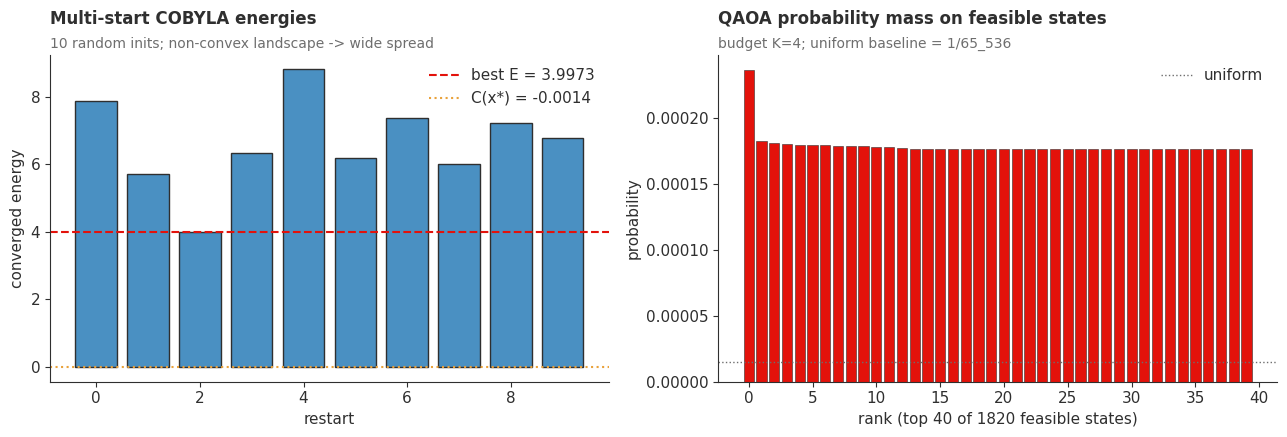

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Multi-seed restart energies — shows the landscape is non-convex
energies = [h['fun'] for h in res['history']]
axes[0].bar(range(len(energies)), energies,
            color=PALETTE['blue_muted'], edgecolor=PALETTE['charcoal'])
axes[0].axhline(res['energy'], color=PALETTE['red'], ls='--', lw=1.5,
                label=f'best E = {res["energy"]:.4f}')
axes[0].axhline(bf.cost, color=PALETTE['ochre'], ls=':', lw=1.5,
                label=f'C(x*) = {bf.cost:.4f}')
axes[0].set_xlabel('restart'); axes[0].set_ylabel('converged energy')
title(axes[0], 'Multi-start COBYLA energies',
      f'{len(energies)} random inits; non-convex landscape -> wide spread')
axes[0].legend()
axes[0].grid(False)

# Probability over budget-feasible bitstrings only (n=16 -> 65k states is too many to plot)
probs = res['probs']
n_states = len(probs)
feas_mask = np.array([bin(k).count('1') == pf.K for k in range(n_states)])
feas_probs = probs[feas_mask]
order = np.argsort(-feas_probs)
top = min(40, len(feas_probs))
axes[1].bar(range(top), feas_probs[order][:top],
            color=PALETTE['red'], edgecolor=PALETTE['charcoal'], linewidth=0.4)
axes[1].set_xlabel(f'rank (top {top} of {len(feas_probs)} feasible states)')
axes[1].set_ylabel('probability')
title(axes[1], 'QAOA probability mass on feasible states',
      f'budget K={pf.K}; uniform baseline = 1/{n_states:_}')
axes[1].axhline(1.0/n_states, color=PALETTE['grey'], ls=':', lw=1, label='uniform')
axes[1].legend()
axes[1].grid(False)

plt.tight_layout()
fig.savefig(fig_path('qaoa', f'single_run_universe_p{P}'), bbox_inches='tight')
plt.show()